Se tiver alguma coisa errada em algum lugar ou caso você tenha dúvidas de qualquer passagem / conteúdo da disciplina, pode me mandar um email ([joao.calazans@usp.br](mailto:joao.calazans@usp.br)).

As resoluções para os demais exercícios estão publicadas idem [aqui](https://github.com/JoaoPCalazans/Waves-and-Lines/tree/main).

##Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

mu0 = constants.mu_0
epsilon0 = constants.epsilon_0
c = constants.speed_of_light

##Funções úteis

In [ ]:
def abs_arg(x):
    magnitude = abs(x)
    angle = np.angle(x) * 180 / np.pi
    print(f'\t|{magnitude}| /_{angle} °')

In [ ]:
# 4.63 e 4.49 na apostila
def eta(epsilon_r=1, freq=1e9, sigma=0, epsilon_im=None, mu_r=1):
  if sigma is None:
    return np.sqrt(mu0*mu_r / epsilon0 / (epsilon_r - 1j*epsilon_im))
  else:
    return np.sqrt(mu0*mu_r / (epsilon0*epsilon_r - 1j*sigma/2/np.pi/freq))

In [ ]:
# 4.61/4.62 e 4.52 na apostila
def k(epsilon_r=1, freq=1e9, sigma=0, epsilon_im=None, mu_r=1):
  if sigma is None:
    return 2*np.pi*freq*np.sqrt(mu0*mu_r*epsilon0 * (epsilon_r - 1j*epsilon_im))
  else:
    return 2*np.pi*freq*np.sqrt(mu0*mu_r * (epsilon0*epsilon_r - 1j*sigma/2/np.pi/freq))

In [ ]:
# 4.53 na apostila
def gamma(epsilon_r=1, freq=1e9, sigma=0, epsilon_im=None, mu_r=1):
  return 1j*k(epsilon_r, freq, sigma, epsilon_im, mu_r)

In [ ]:
# 4.67 na apostila
def delta(sigma=5.8e7, freq=1e9, mu_r=1):
  return 1/np.sqrt(np.pi * freq * mu_r*mu0 * sigma)

In [ ]:
# 4.78 na apostila (para onda em 0 incidindo em 1 (e refletindo de volta para 0))
def rho(eta0, eta1):
  return (eta1 - eta0) / (eta1 + eta0)

In [ ]:
# 4.84 na apostila
def impedancia(eta, rho):
  return eta*(1+rho)/(1-rho)

In [ ]:
# 3.19 na apostila
def vf(epsilon_r=1, freq=1e9, sigma=0, epsilon_im=None, mu_r=1):
  return 2*np.pi*freq / np.real(k(epsilon_r, freq, sigma, epsilon_im, mu_r))

##Lista 2 - Exercício 22.

Considere o sistema de transmissão esquematizado:

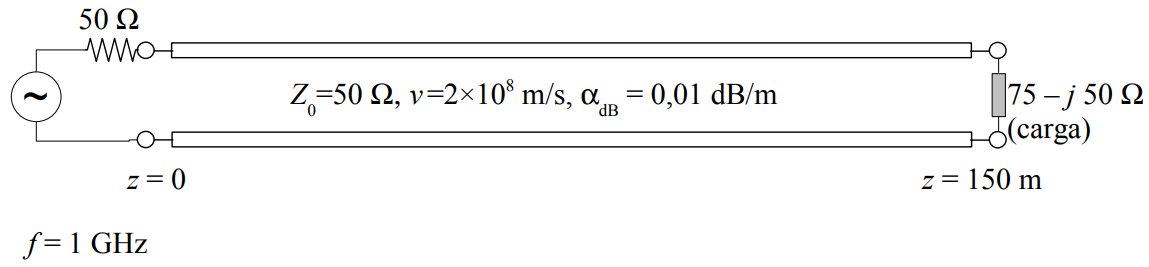

Lembrete: potência disponível de um gerador é a máxima potência que ele pode fornecer.

Calcular:

###a) a atenuação total da linha;

$\rho_{L} = \frac{75-j50 - 50}{75-j50 + 50} = 0,4152\angle{-41,6^\circ}$

$|\rho_{ent}| = |\rho_{L}\times10^{-\frac{\alpha_{dB}L}{10}}\times e^{-2j\frac{2\pi}{\lambda}L}| = |\rho_{L}|\times10^{-\frac{0,01\times150}{10}} = 0,2940 $

$A_{dB} = \alpha_{dB}L + 10\,log_{10}\left( \frac{1-|\rho_{ent}|^2}{1-|\rho_{L}|^2} \right) = 0,01 \times 150 + 10\,log_{10}\left( \frac{0,9136}{0,8275} \right) = 1,929 \,\,\, dB$

In [ ]:
f = 1e9
Z_L = 75 - 1j*50

Z_0 = 50
v = 2e8
alpha = 0.01
L = 150

# ----

rho_L = rho(Z_0, Z_L)
rho_ent = rho_L * np.exp(-4j*np.pi*f/v*L) * 10**(-alpha*L/10)

# print(f'rho_L =')
# abs_arg(rho_L)
# print(f'rho_ent =')
# abs_arg(rho_ent)
# print()

# print(f'1 - |rho_L|^2 = {1 - np.abs(rho_L)**2}')
# print(f'1 - |rho_ent|^2 = {1 - np.abs(rho_ent)**2}')

AdB = alpha*L + 10*np.log10((1 - np.abs(rho_ent)**2) / (1 - np.abs(rho_L)**2))

print(f'AdB = {AdB} dB')

AdB = 1.9293733660793295 dB


###b) eficiência do sistema de transmissão ( $\eta = \frac{P_{carga}}{P_{disponivel}}\times100\% $);

$\eta_{\%} = \frac{P_{carga}}{P_{disp}} = \frac{P_{en}\times A}{P_{disp}} = \frac{P_{disp}\times(1-|\rho_{ent}|^2)\times A}{P_{disp}} = (1-|\rho_{ent}|^2) \times 10^{-\frac{A_{dB}}{10}} = 58,59 \%$

In [ ]:
eficiencia = (1 - np.abs(rho_ent)**2) * 10**(-AdB/10)

print(f'eta = {eficiencia*100} %')

eta = 58.58861663868728 %


###c) projetar um casador por toco simples em curto-circuito para ser colocado o mais próximo possível da carga;

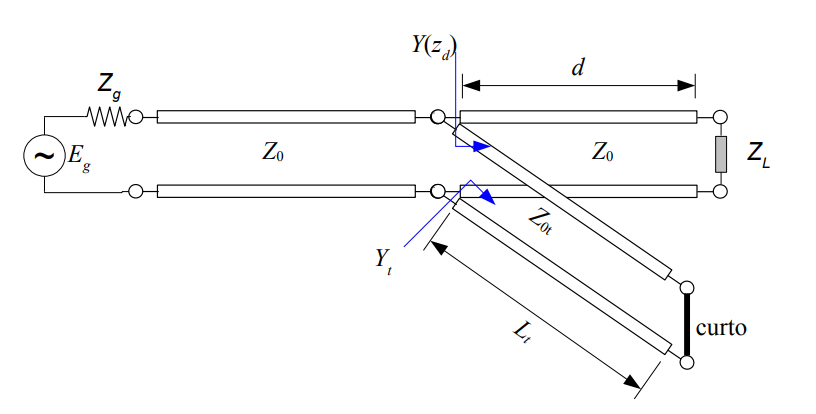

Como o casamento de impedância se dará por associações paralelos, é conveniente usar admitâncias. Deseja-se que os pontos $z < z_d$ tenham admitância normalizada vista de $y(z) = Z_0 / Z(z) = Z_0\times Y(z) = 1$ (ou seja, de impedância efetiva $Z_0$).

Para tal, serão consideradas a admitância [normalizada] no ponto de casamento devido a carga $y(z_d) = g + jb$ e a admitância [normalizada] do toco $y_t = -jb$.
Repare que a soma é $g$, ou seja, basta escolher um ponto $z_d=L-d$ tal que $g=1$.

Pela carta de Smith é fácil, basta partir da carga e girar até o momento em que se atinge a circunferência de condutâncias unitárias.
O comprimento girado resulta na distância $d$ (normalizada em comprimentos de onda), e o ponto lido fornece $b$.

Novamente pela carta, agora conhecidos $b$ e $Z_{0t}$, acha-se $L_t$ em função de $\lambda_t$. Particularmente nesse caso, o toco é do mesmo material da outra linha e $Z_{0t}=Z_0$ e $\lambda_t=\lambda$.

---

Temos $y(L) = 0,462 + j0,308$, correspondendo a $0,058\lambda$ na carta (escala de fora, traçado em preto e roxo na figura abaixo).

Girando até a circunferência unitária, sentido gerador, para-se no ponto de $0,160\lambda$ e $y(z_d) = 1 + j0,95$, ou seja:

$d = (0,160 - 0,058)\lambda = 0,102\lambda = 2,04\,\,\,cm$

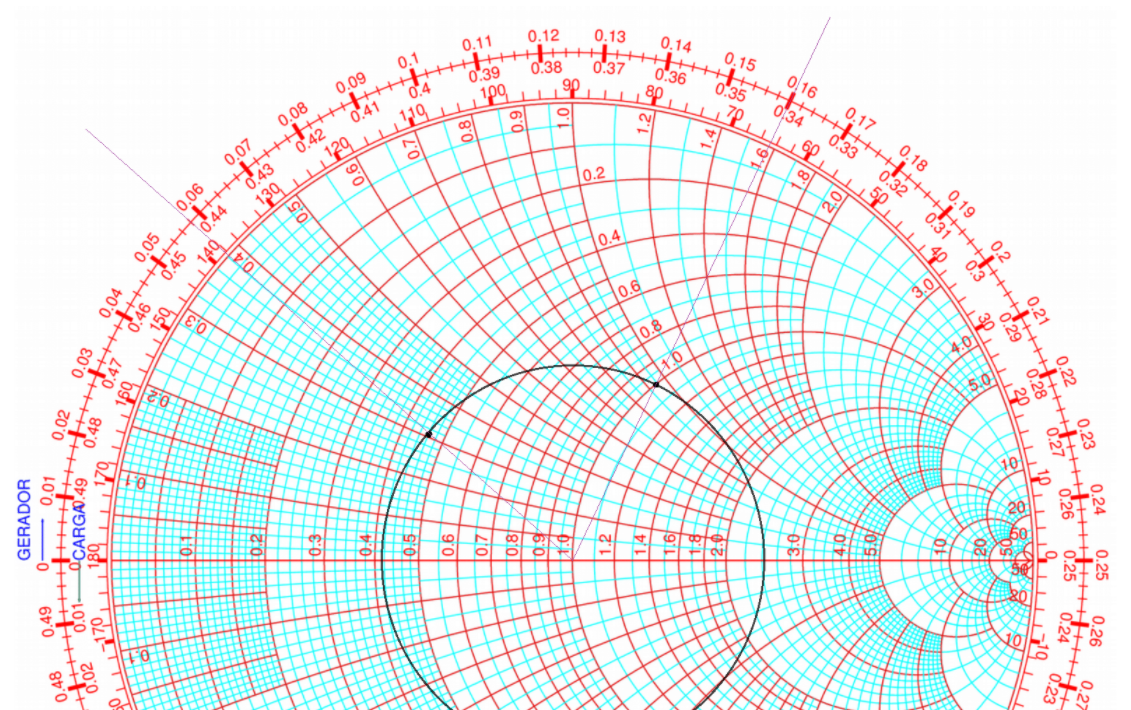

Sabendo $b=0,95$, vamos achar $L_t$, figura abaixo, traçados em verde.

Achando o ponto $y_t=-j0,95$ na carta, gira-se até o curto $y_{curto}=\infty$ (impedância 0).
Desta vez, parte-se do ponto mais próximo ao gerador e direciona-se a terminação, ou seja, sentido da carga / anti-horário / escala de dentro.

Partindo de $0,121\lambda$, chegamos em $0,250\lambda$, andando então $L_t = (0,250 - 0,121)\lambda = 0,129\lambda = 2,58\,\,\,cm$

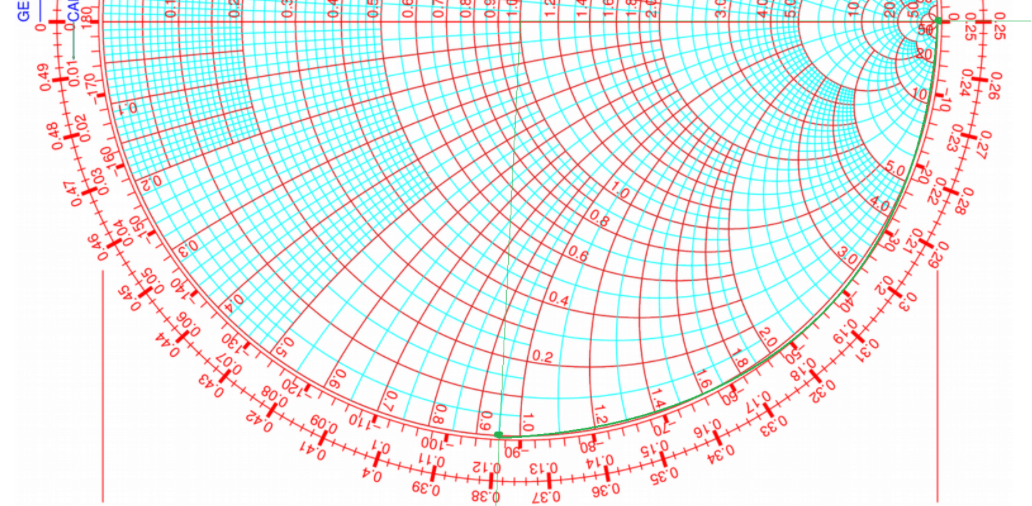

---

Vou explicar brevemente como eu gosto de resolver sem a carta.
Breve, porque não acredito haver necessidade de aprender este truque.
Não obstante, apresento mesmo assim por preferência pessoal.

Considere um ponto que esteja na circunferência unitária. Vou adotar o lado superior sem perda de generalidade. Traçando uma reta deste ponto ao centro da carta, outra até o ponto de impedância infinita, e ligando-as, forma-se um triângulo inscrito [na semi-circunferência]. A partir daí, fica fácil de ver é que este é um triângulo retângulo (trace por exemplo uma reta auxiliar pela bissetriz de $A\hat{C}B$ e veja os ângulos internos dos dois triângulos isóceles resultantes).

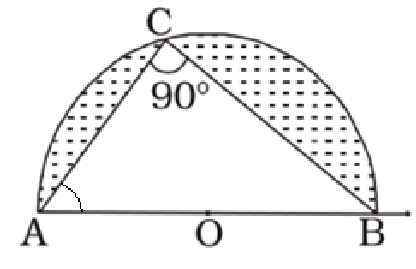

Como a base $\vec{AB}=1$, tira-se que o ângulo $C\hat{A}B$ é simplesmente $cos^{-1}(\vec{AC}/\vec{AB})=cos^{-1}(\vec{AC})$.

Voltando ao problema com a linha, vamos analisar os pontos de partida na carta.
No plano cartesiano, os eixos reais e imaginário correspondem às parcelas do coeficiente de reflexão (ou seja, o centro da carta é $|\rho|=0$ e a circunferência externa é $|\rho|=1$. Num ponto genérico, o ângulo deste ponto é a fase e a distância ao centro é o módulo de $\rho$).

O problema de determinar uma distância (ou fase) virá então apenas um problema de achar diferença de ângulos, dados os pontos iniciais [e finais!].
Só chamo a atenção ao ponto inicial: estamos trabalhando com admitâncias, então some $180^\circ / \pi$ ao valor convencional de coef. de reflexão para impedância.

No triângulo mencionado, o ângulo $C\hat{A}B$ é sua fase final, e o lado $\vec{AC}$ é o módulo de $|\rho|$ (que pode ser assumido como igual ao inicial para distâncias curtas).

A diferença de fase de $\rho$ entre dois pontos distantes de $d$ leva a:

$\Phi(z_d) = (\Phi+\pi)_L - \frac{4\pi}{\lambda}d \rightarrow d = \frac{\lambda}{4\pi}\left( (\Phi + \pi)_L - cos^{-1}(|\rho_L|) \right)$

Conhecido $d$, determina-se então $y(z_d)$ e $b$.

Assim, acha-se $y_t$ e $\rho_t$, ambos em relação à entrada do toco. Aplicando a mesma relação de fases:

$\Phi_{curto} = \pi = \Phi_t + \frac{4\pi}{\lambda}L_t \rightarrow L_t = \frac{\lambda}{4\times\pi}\left( \pi - \Phi_t \right) = \frac{\lambda}{4}\left( 1 - \frac{\Phi_t}{\pi} \right)$

Onde $\Phi_t$ é a fase do coeficiente de reflexão de $Z_t=1/Y_t$ em relação a $Z_{0t}$. No nosso caso particular, $Z_{0t}=Z_0$, então $y_t=Y_t\times Z_0 = -jb$

In [ ]:
d = v/f / 4/np.pi * (np.angle(rho_L) + np.pi - np.acos(np.abs(rho_L)))

rho_d = rho_L * np.exp(-4j*np.pi*f/v*d) * 10**(-alpha*d/10)
y_d = (1 - rho_d) / (1 + rho_d)

y_t = -1j*np.imag(y_d)
rho_t = (1 - y_t) / (1 + y_t)

Lt = v/f/4 * (1 - np.angle(rho_t)/np.pi)

print(f'd = {d*1e2} cm')

print(f'Lt = {Lt*1e2} cm')

d = 2.0250027326764397 cm
Lt = 2.644960252281611 cm


###d) desprezando-se as perdas do toco e do trecho entre a carga e o toco, repetir os itens a e b;

$A_{dB} = \alpha_{dB}(L-d) = 1,50 \,\,\, dB$

Os trechos entre carga e toco (de tamanho $d$) foram desprezados. Como é curto, não afetou de verdade o resultado.

Repare que, idem por isso, as reflexões sumiram.

In [ ]:
AdB = alpha*(L-d)

print(f'AdB = {AdB} dB')

AdB = 1.4997974997267323 dB


$\eta_{\%} = \frac{P_{disp}\times(1-|\rho_{ent}|^2)\times A}{P_{disp}} = A = 10^{-\frac{A_{dB}}{10}} = 70,8 \%$

Pois agora, $\rho_{ent}=0$.

In [ ]:
eficiencia = 10**(-AdB/10)

print(f'eta = {eficiencia*100} %')

eta = 70.79787948328212 %


###e) projetar um casador por transformador de $\lambda/4$ para ser colocado o mais próximo possível do gerador;

No topo do colab, deixei disponível um link para meu GitHub. Tanto lá, quanto no Moodle e no [Polishare](https://www.polishare.com.br/index.php?id=qQWj) há um pdf com a resolução deste item conforme foi pedido, de casamento mais próximo ao gerador.

Porém, como é mais usual fazer o casamento mais próximo à carga, e é assim que procedi a seguir.

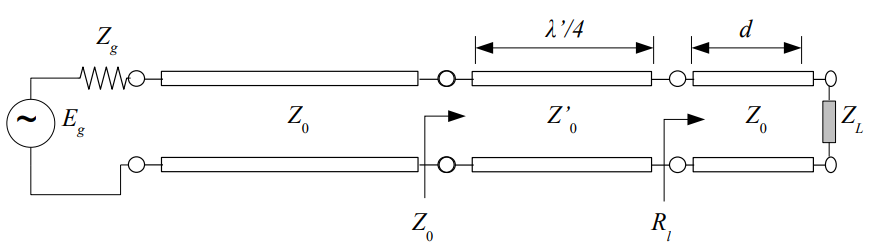

Para o casamento, primeiro determina-se a distância mais próxima a carga (para menores distorções) em que a impedância assume um valor real. Pela carta de Smith, acha-se fácil pelo momento em que cruza-se a linha de parte complexa = 0 (linha horizontal central).

Particularmente, gosto de analisar pelo ponto em que o coeficiente de reflexão, a partir da carga, atinge um ponto de fase 0 (ou $180^\circ$, a mais perto das duas), já que posso fazer tudo formulaticamente.
Para isso, considere a expressão:

$\rho(z_1) = \rho_{L}\times e^{2j\frac{2\pi}{\lambda}(z_1-L)}\times10^{\frac{\alpha_{dB}(z_1-L)}{10}} = |\rho_{L}|\times e^{j(\Phi + \frac{4\pi}{\lambda}(z_1-L))}\times10^{\frac{\alpha_{dB}(z_1-L)}{10}}$

A fase $\Phi_{rad}$ de $\rho_L$ soma-se ao termo $\frac{4\pi}{\lambda}(z_1-L)$, sendo que essa diferença de distâncias ($z_1-L=-d$) torna-a real em $\Phi_{graus} - \frac{4\times180^\circ}{\lambda}d = n\times180^\circ$, com $n\in\mathbb{Z}$ e proporcional à distância à carga.

No caso particular desta questão ($\Phi_{graus} = -41,6^\circ$), o $n$ de menor $d$ é -1, e:

$d = \frac{180^\circ-41,6^\circ}{4\times180^\circ}\lambda = 0,192\lambda = 3,844 \,\,\,cm$

É fácil demonstrar que nessas linhas em RPS, a impedância de um dos lados, $Z_{1}$, de um trecho de $\lambda/4$ e impedância característica $Z_{0}'$ pode ser expressa em função da impedância $Z_2$, da outra entrada, como: $Z_1 = \frac{Z_0'^2}{Z_2}$ (Para visualizar isso facilmente, imagine que você parte de um ponto qualquer da carta de Smith. Partindo deste ponto e girando $\lambda/4$, você chegará em um outro diametralmente oposto. Considerando isso, pergunte-se: o que acontece se você parte de um ponto com impedância puramente real? O ponto final também é real? Então para chegar em um qualquer, idem real, após $\lambda/4$, o que é necessário?).

No problema de transformador de impedância, a impedância para o resto do trecho deve ser $Z_1=Z_0$. Como esta e $Z_0'$ são necessariamente reais, $Z_2$ é escolhido idem como real, particularmente, o mais próximo possível da carga ($Z_2=Z(z_1)$, com $z_1=L-d$ achado acima).

Manipulando a expressão:

$Z_0' = \sqrt{Z(z_1)\times Z_0} = 32,142 \,\,\,\Omega$

e

$L'=\frac{\lambda}{4} = 5 \,\,\,cm$

In [ ]:
d = (np.pi + np.angle(rho_L))/np.pi/4 * v / f

rho_d = rho_L * np.exp(-4j*np.pi*f/v*d) * 10**(-alpha*d/10)
Z_d = Z_0 * (1 + rho_d) / (1 - rho_d)

Z_0t = np.sqrt(Z_0 * Z_d)
Lt = v / f / 4

print(f'd = {d*1e2} cm')
# print(f'Z_d (Ohms) =')
# abs_arg(Z_d)
print(f'Z_0t (Ohms) =')
abs_arg(Z_0t)
print(f'Lt = {Lt*1e2} cm')

d = 3.843512796206383 cm
Z_0t (Ohms) =
	|32.14176201427942| /_-1.3449409565050642e-14 °
Lt = 5.0 cm


###f) desprezando-se a perda do transformador de $\lambda/4$, repetir os itens a e b;

$A_{dB} = \alpha_{dB}L + 10\,log_{10}\left( \frac{1-|\rho(z_1)|^2}{1-|\rho_{L}|^2} \right) = 1,50 \,\,\, dB$

Repare que, após o casamento, o termo que depende das reflexões tornou-se desprezível.

In [ ]:
AdB = alpha*L + 10*np.log10((1 - np.abs(rho_d)**2) / (1 - np.abs(rho_L)**2))

print(f'AdB = {AdB} dB')

AdB = 1.5001601292422575 dB


$\eta_{\%} = \frac{P_{disp}\times(1-|\rho_{ent}|^2)\times A}{P_{disp}} = 10^{-\frac{A_{dB}}{10}} = 70,8 \%$

Pois agora, $\rho_{ent}=0$.

In [ ]:
eficiencia = 10**(-AdB/10)

print(f'eta = {eficiencia*100} %')

eta = 70.79196821109443 %


###g) qual dos dois esquemas de casamento você usaria? Por quê?

Fica para o leitor :)

Lembrando que eu resolvi os itens (e) e (f) diferentemente do pedido, melhorando a eficiência.

##Lista 3 - Exercício 16.

Uma onda plana uniforme possui
$\dot{\vec{E}}_+(z=0)=E_0\hat{u}_x + jE_0\hat{u}_y$
com $E_0$ = 2 mVef/m.
Esta onda propaga-se no vácuo ($\eta_0=377\,\Omega$ e $c=3\times10^8$ m/s) no sentido de $z>0$. Pedem-se:

###a) constante de propagação e comprimento de onda se a frequência da oscilação for 10 GHz;

$\gamma = jk = j\,\omega\sqrt{\mu\epsilon} = j\,2\pi 10^{10}\sqrt{\mu_0\epsilon_0} = j\,\frac{200\pi}{3} \,\,\, m^{-1}$

$\lambda = \frac{c}{f} = \frac{3\times10^8}{10^{10}} = 3\times10^{-2} \,\,\, m= 3 \,\,\, cm$

In [ ]:
f = 10e9
gamma_0 = gamma(epsilon_r=1, freq=f, sigma=0)
lambda_0 = 2*np.pi/np.imag(gamma_0) # = c / f

print(f'gamma = {gamma_0} 1/m')
print(f'lambda = {lambda_0*1e2} cm')

gamma = 209.58450219529323j 1/m
lambda = 2.9979245799982115 cm


###b) polarização da onda incidente;

Como $|E_x| = |E_y|$, a polarização é possivelmente circular, dependendo apenas da fase para determinar.

Por ter $\phi_y - \phi_x = \pi/2 - 0 = +\pi/2$, sabe-se que o campo começa no eixo x e vai para y ($90^\circ$ adiantado) com o passar do tempo (apontando para +z), ou seja, é circular e à esquerda (LHCP).

<video width="640" height="360" controls>
  <source src="https://raw.githubusercontent.com/JoaoPCalazans/Waves-and-Lines/main/37826_360p.mp4" type="video/mp4">
</video>

###c) supondo que esta onda incida num condutor imperfeito ($\epsilon=\epsilon_0$; $\sigma=4$ S/m) semi-infinito, determine a expressão fasorial da onda refletida e sua expressão temporal (campo elétrico apenas);

$\eta_{cond} \approx (1+j)\sqrt{\frac{\pi f \mu}{\sigma}} = (1+j)\sqrt{\frac{\pi 10^{10} \mu_0}{4}} = 140,5 \angle{45^\circ} \,\,\, \Omega$

$\rho_0 = \frac{\eta_{cond} - \eta_0}{\eta_{cond} + \eta_0} = 0,583\angle{150,52^\circ}$

In [ ]:
eta_0 = eta(epsilon_r=1, freq=f, sigma=0)
eta_cond = eta(epsilon_r=1, freq=f, sigma=4)

print(f'eta_cond = {eta_cond} Ohm')
abs_arg(eta_cond)
print(f'aproximado como')
abs_arg((1+1j)*np.sqrt(f*np.pi*mu0/4))

rho_0 = rho(eta_0, eta_cond)

print(f'rho_0 = {rho_0}')
abs_arg(rho_0)

eta_cond = (105.46155146481206+91.80894365240441j) Ohm
	|139.82496548161765| /_41.0410121440129 °
aproximado como
	|140.49629461153947| /_45.0 °
rho_0 = (-0.5079097971383346+0.2871048138354754j)
	|0.5834394023003651| /_150.5219426316923 °


$\dot{\vec{E}}_-(z) = \rho_0 E_0 e^{+\gamma z} \hat{u}_x + j\rho_0 E_0 e^{+\gamma z} \hat{u}_y = \rho_0 E_0 e^{+\gamma z} [\hat{u}_x + j \hat{u}_y] = 1,167\,e^{j(209,585z + 2,627)} [\hat{u}_x + j \hat{u}_y] \,\,\, mVef/m$

$\vec{E}_-(z,t) = \mathcal{Re}\{ \sqrt{2}\,\dot{\vec{E}}_-(z)\,e^{j\omega t}\} = 1,167\sqrt{2}\,[cos(2\pi10^{10}t + 209,585z + 2,627)\hat{u}_x - sen(2\pi10^{10}t + 209,585z + 2,627)\hat{u}_y] \,\,\, mVef/m$

###d) quais as polarizações da onda refletida no vácuo e da onda transmitida no condutor? Justifique;

A onda refletida propaga-se no sentido de -z, e nessa referência a defasagem $\phi_y - \phi_x = +\pi/2$ traduz-se como circular à direita (RHCP).

A transmitida permanece como à esquerda.

###e) determine a expressão fasorial do campo elétrico da onda estacionária resultante no vácuo;

Para z<0 (vácuo):

$\dot{\vec{E}}(z) = \dot{\vec{E}}_+(z) + \dot{\vec{E}}_-(z) = E_0 e^{-\gamma z} [\hat{u}_x + j\hat{u}_y] (1 + \rho_0 e^{+2\gamma z}) = 0,002\,e^{-209,585 z} [\hat{u}_x + j\hat{u}_y] (1 + \rho_0 e^{419,169 z}) \,\,\, Vef/m$

###f) esboce a amplitude da onda estacionária (campo elétrico) no vácuo e da onda transmitida no condutor, em função de z.

In [ ]:
gamma_1 = gamma(1, f, 4)
L = 2*lambda_0

z = np.linspace(-L, L, 1000)
z0 = z[z <= 0]
z1 = z[z > 0]

E0_inc = 2 * np.sqrt(2) * np.exp(1j*np.pi/4) # mVef/m

E0 = E0_inc * np.exp(-gamma_0 * z0) + E0_inc * rho_0 * np.exp(gamma_0 * z0)

E1_inc = E0[-1]
E1 = E1_inc * np.exp(-gamma_1 * z1)

# z_total = np.concatenate((z0, z1))
# E_total = np.concatenate((E0, E1))
# print(abs(E_total[z == 0]))

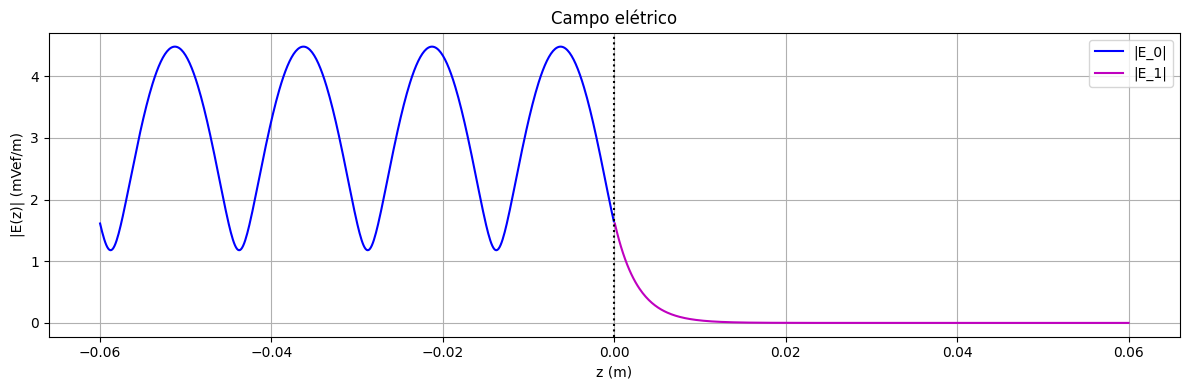

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(z0, np.abs(E0), c='b', label='|E_0|')
plt.plot(z1, np.abs(E1), c='m', label='|E_1|')

# plt.plot(z_total, np.abs(E_total), c='k', ls='--', label='|E|')

plt.axvline(0, c='k', ls=':')

plt.xlabel('z (m)')
plt.ylabel('|E(z)| (mVef/m)')
plt.title('Campo elétrico')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Lista 3 - Exercício 27.

Uma fatia de dielétrico ($\epsilon' – j \epsilon''$) de comprimento L está encostada em um plano condutor perfeito.
Determine a expressão da impedância de onda na interface dielétrico/vácuo.

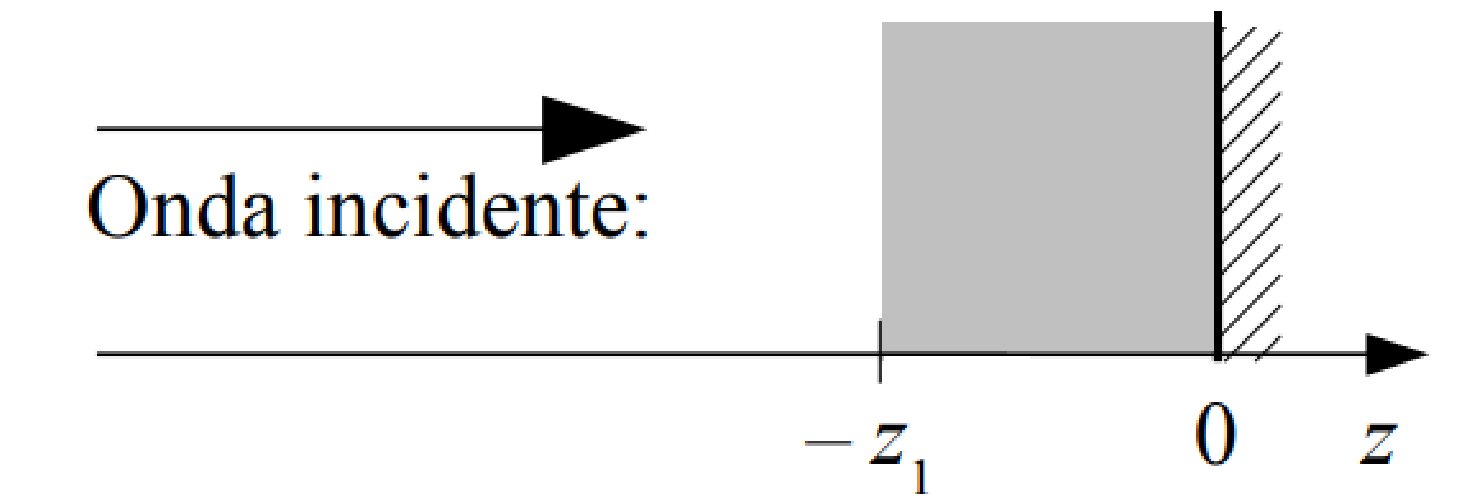

$\rho_{diel}(z=0) = \frac{\eta_{cond}-\eta_{diel}}{\eta_{cond}+\eta_{diel}} = -1$

$\rho_{diel}(z=-z_1) = \rho_{diel}(0)\,e^{j\,2k_{diel}\,(-z_1)} = -e^{-j\,2k_{diel}\,L}$

$Z(z=-z_1) = \eta_{diel}\,\frac{1+\rho_{diel}(-z_1)}{1-\rho_{diel}(-z_1)}$

Com:

$k_{diel} \approx \omega\sqrt{\mu\epsilon'}\,\left(1-j\frac{\epsilon''}{2\epsilon'}\right)$
e
$\eta_{diel} \approx \sqrt{\frac{\mu}{\epsilon'}}$

---

Calcule os valores para $\epsilon'=4 \epsilon_0$, $\epsilon''=0,01 \epsilon_0$, f = 3 GHz e L = 1,25 cm.

In [ ]:
L = 1.25e-2
f = 3e9
k_diel = k(epsilon_r=4, freq=f, epsilon_im=0.01)
eta_diel = eta(epsilon_r=4, freq=f, epsilon_im=0.01)

# print(f'eta_diel = {eta_diel} Ohms')

rho_L = -np.exp(-1j*2*k_diel*L)
Z_L = eta_diel * (1 + rho_L) / (1 - rho_L)

print(f'rho(z=-L) = {rho_L}')
abs_arg(rho_L)

print(f'Z(z=-L) = {Z_L} Ohms =')
abs_arg(Z_L)

rho(z=-L) = (0.9999976349508614-0.0021748776250397994j)
	|1.0| /_-0.12461140710959898 °
Z(z=-L) = (-2.8927624817886636e-09-173218.88072302894j) Ohms =
	|173218.88072302894| /_-90.00000000000097 °


$\frac{L}{\lambda_{diel}} \approx 1/4$, ou seja, o efeito do condutor aparece na interface dielétrico/vácuo como um aberto ($Z: 0 \rightarrow \infty$).

##Lista 3 - Exercício 28.

Uma onda plana, polarizada linearmente na direção x, propaga-se no sentido positivo de z, incidindo na estrutura mostrada abaixo.

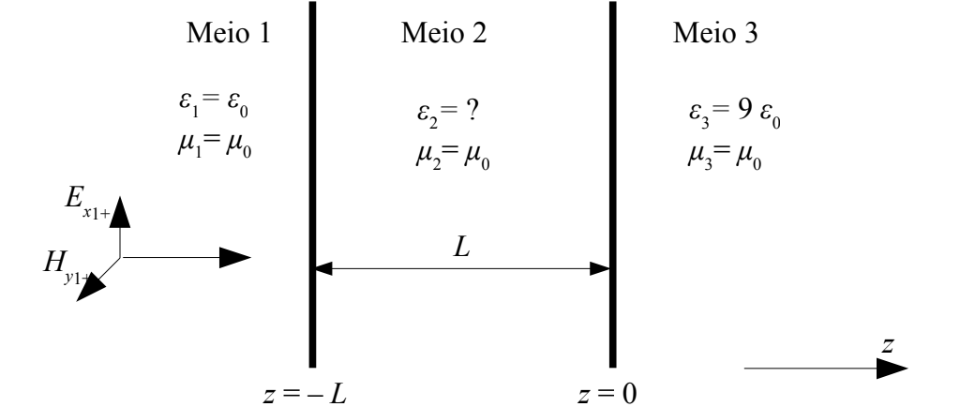

Essa onda varia senoidalmente no tempo, na frequência de 1 GHz, tendo valor eficaz de 1 Vef/m e fase nula em $z = 0: \dot{\vec{E}} = 1\,e^{-j k_1 z}\hat{u}_x$.

###a) Determine as impedâncias intrínsecas ($\eta_1$ e $\eta_3$) e as constantes de propagação ($k_1$ e $k_3$) dos meios 1 e 3.

In [ ]:
epsilon_1 = 1
epsilon_3 = 9
freq = 1e9

In [ ]:
eta_1 = eta(epsilon_1)
eta_3 = eta(epsilon_3)
k_1 = k(epsilon_1, freq, 0)
k_3 = k(epsilon_3, freq, 0)

print(f'eta_1 = {eta_1} Ohms\neta_3 = {eta_3} Ohms\n')
print(f'k_1 = {k_1} rad/m\nk_3 = {k_3} rad/m\n')

eta_1 = (376.7303134118051+0j) Ohms
eta_3 = (125.57677113726837+0j) Ohms

k_1 = (20.958450219529325+0j) rad/m
k_3 = (62.875350658587976+0j) rad/m



###b) Deseja-se a máxima transferência de potência do meio 1 para o meio 3. Determine os valores de $\epsilon_2$ e L (em m) que satisfazem esta condição na frequência de 1 GHz. (L deve ter o menor valor possível).

In [ ]:
epsilon_2 = np.sqrt(epsilon_1 * epsilon_3)
eta_2 = eta(epsilon_2, freq, 0)
print(f'epsilon_2 = {epsilon_2} * epsilon_0\n')

lambda_2 = vf(epsilon_2, freq, 0) / freq
L = lambda_2/4
print(f'L = {L} m = {lambda_2/0.04} cm')

epsilon_2 = 3.0 * epsilon_0

L = 0.04327131408180407 m = 4.327131408180406 cm


###c) Ainda na mesma frequência, calcule os coeficientes de reflexão, $\rho_1(-L)$, $\rho_2(-L)$, $\rho_2(0)$, $\rho_3(0)$ nas interfaces.

In [ ]:
print(f'rho_3 = {0}')

rho_2_0 = rho(eta_2, eta_3) # z = 0
print(f'rho_2(0) =')
abs_arg(rho_2_0)

gamma_2 = gamma(epsilon_2, freq, 0)
rho_2_L = rho_2_0 * np.exp(2*gamma_2*-L)
print(f'rho_2(-L) =')
abs_arg(rho_2_L)

rho_3 = 0
rho_2(0) =
	|0.26794919243112264| /_180.0 °
rho_2(-L) =
	|0.26794919243112264| /_7.016709298534877e-15 °


In [ ]:
Z_2 = impedancia(eta_2, rho_2_L)
print(f'Z_2 = {Z_2:.2f} Ohms\n')

rho_1_L = rho(eta_1, Z_2)
print(f'rho_1(-L) = {rho_1_L:.1f} = ')
abs_arg(rho_1_L)

Z_2 = 376.73+0.00j Ohms

rho_1(-L) = -0.0+0.0j = 
	|2.290737350506856e-16| /_171.12217125727335 °


###d) Lembrando que, como os meios não têm perdas, o vetor de Poynting médio tem o mesmo valor nos 3 meios, calcule o valor eficaz do campo elétrico no meio 3 nessas condições e esboce o gráfico do valor eficaz do campo elétrico nos 3 meios.

In [ ]:
E_1_L = 1 # incidente, ux
E_1_L_total = 1 * (1 + rho_1_L) # total, ux
N_1 = abs(E_1_L_total)**2 / eta_1
N_3 = N_1
E_3_0 = np.sqrt(N_3 * eta_3) # total, fase 0, ux

print(f'|E_3| = {abs(E_3_0)} Vef/m')

|E_3| = 0.5773502691896256 Vef/m


In [ ]:
z = np.linspace(-2*L, L, 1000)
z1 = z[z < -L]
z2 = z[(z >= -L) & (z <= 0)]
z3 = z[z > 0]

gamma_1 = gamma(epsilon_1, freq, 0)
gamma_2 = gamma(epsilon_2, freq, 0)
gamma_3 = gamma(epsilon_3, freq, 0)

E1 = E_1_L * np.exp(-gamma_1 * z1) + E_1_L * rho_1_L * np.exp(2*gamma_1*L) * np.exp(gamma_1 * z1)

E_2_L = E1[-1] / (1 + rho_2_L) / np.exp(gamma_2*L) # incidente, ux
E2 = E_2_L * np.exp(-gamma_2 * z2) + E_2_L * rho_2_0 * np.exp(gamma_2 * z2)

E_3_0 = E2[-1]
E3 = E_3_0 * np.exp(-gamma_3 * z3)

# z_total = np.concatenate((z1, z2, z3))
# E_total = np.concatenate((E1, E2, E3))
# print(abs(E_total[z == 0]))

print(f'|E_3| = {abs(E3[0])} Vef/m')

|E_3| = 0.5773502691896257 Vef/m


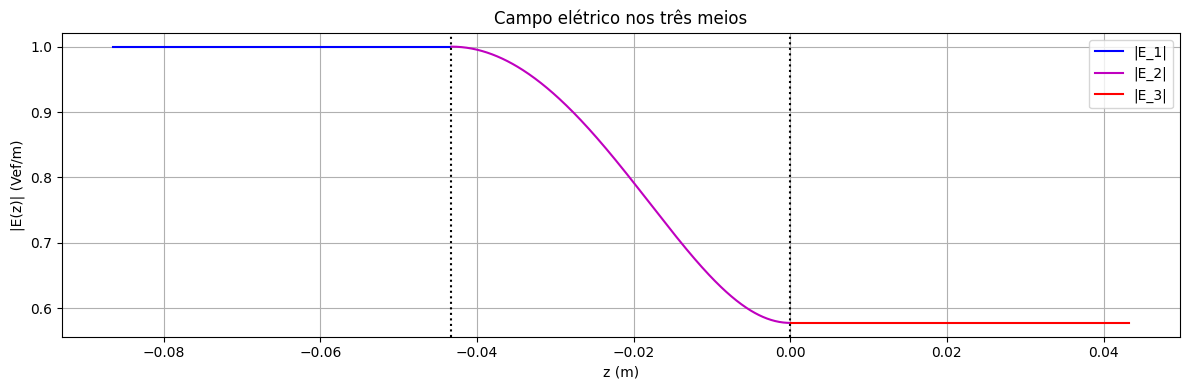

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(z1, np.abs(E1), c='b', label='|E_1|')
plt.plot(z2, np.abs(E2), c='m', label='|E_2|')
plt.plot(z3, np.abs(E3), c='r', label='|E_3|')

# plt.plot(z_total, np.abs(E_total), c='k', ls='--', label='|E|')

plt.axvline(-L, c='k', ls=':')
plt.axvline(0, c='k', ls=':')

plt.xlabel('z (m)')
plt.ylabel('|E(z)| (Vef/m)')
plt.title('Campo elétrico nos três meios')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<video width="640" height="360" controls>
  <source src="https://raw.githubusercontent.com/JoaoPCalazans/Waves-and-Lines/main/37937_360p.mp4" type="video/mp4">
</video>

###e) Determine o valor eficaz do campo magnético nos meios 1 e 3 e esboce o gráfico do valor eficaz do campo magnético nos 3 meios.

In [ ]:
H_1 = E_1_L_total/eta_1 # total, uy
H_3 = E_3_0/eta_3 # total, fase 0, uy

print(f'|H_1| = {abs(H_1)} Aef/m')
print(f'|H_3| = {abs(H_3)} Aef/m')

|H_1| = 0.002654418729790126 Aef/m
|H_3| = 0.004597588104558943 Aef/m


In [ ]:
H_1_L = 1/eta_1 # incidente, uy
H1 = H_1_L * np.exp(-gamma_1 * z1) - H_1_L * rho_1_L * np.exp(2*gamma_1*L) * np.exp(gamma_1 * z1)

H_2_L = H1[-1] / (1 - rho_2_L) / np.exp(gamma_2*L) # incidente, uy
H2 = H_2_L * np.exp(-gamma_2 * z2) - H_2_L * rho_2_0 * np.exp(gamma_2 * z2)

H_3_0 = H2[-1]
H3 = H_3_0 * np.exp(-gamma_3 * z3)

# z_total = np.concatenate((z1, z2, z3))
# H_total = np.concatenate((H1, H2, H3))
# print(abs(H_total[z == 0]))

print(f'|H_1| = {abs(H1[0])} Aef/m')
print(f'|H_3| = {abs(H3[0])} Aef/m')

|H_1| = 0.002654418729790126 Aef/m
|H_3| = 0.004597588104558942 Aef/m


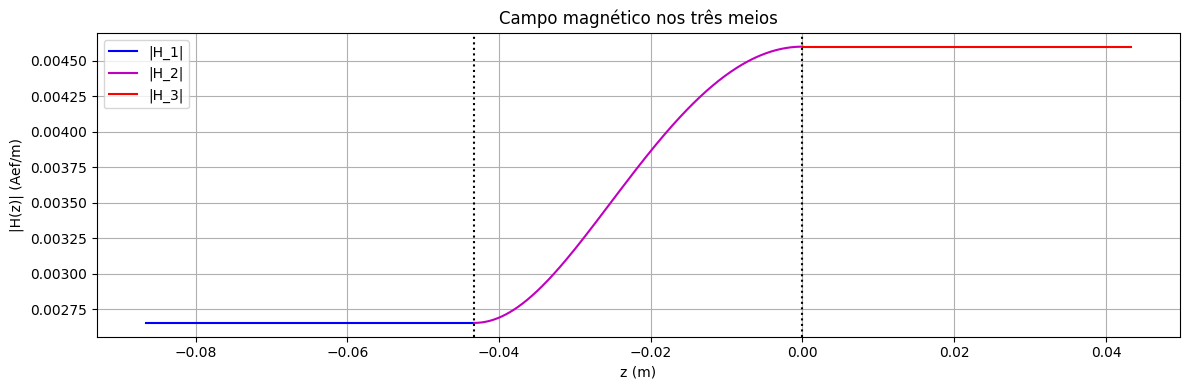

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(z1, np.abs(H1), c='b', label='|H_1|')
plt.plot(z2, np.abs(H2), c='m', label='|H_2|')
plt.plot(z3, np.abs(H3), c='r', label='|H_3|')

# plt.plot(z_total, np.abs(H_total), c='k', ls='--', label='|H|')

plt.axvline(-L, c='k', ls=':')
plt.axvline(0, c='k', ls=':')

plt.xlabel('z (m)')
plt.ylabel('|H(z)| (Aef/m)')
plt.title('Campo magnético nos três meios')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###f) Se a estrutura, com o mesmo valor de L calculado em b), for excitada na frequência de 2 GHz, qual será o valor da impedância de onda em $z = -L$ , $Z(z = -L)$, e qual será o valor do coeficiente de reflexão $\rho_1(-L)$?

In [ ]:
freq2 = 2*freq

gamma_2_2 = gamma(epsilon_2, freq2, 0)
rho_2_L_2 = rho_2_0 * np.exp(2*gamma_2_2*-L)

Z_L_2 = impedancia(eta_2, rho_2_L_2)
print(f'Z(-L) = {Z_L_2:.2f}\n')

rho_1_L_2 = rho(eta_1, Z_L_2)
print(f'rho_1(-L) = {rho_1_L_2:.1f} = ')
abs_arg(rho_1_L_2)

Z(-L) = 125.58-0.00j

rho_1(-L) = -0.5-0.0j = 
	|0.49999999999999994| /_-180.0 °


##Break 2